In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.signal import savgol_filter
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)


In [21]:
SIZE_TITLE = 42     
SIZE_LABEL = 42      # axis t, Nssp, P, d(P)
SIZE_TICK = 38        
SIZE_LEGEND = 32       
SIZE_LEGEND_KDE = 22  
SIZE_SPATIAL_TITLE = 38 
SIZE_INSET_TICK = 32  

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

In [22]:


h_times = {
    r'G = 0.05B, $\sigma_e$ = 0.05': [1, 10, 200, 5000],
    r'G = 0.05B, $\sigma_e$ = 0.40': [1, 10, 300, 5000],
    r'G = 0.30B, $\sigma_e$ = 0.05': [1, 1000, 1500, 5000],
    r'G = 0.30B, $\sigma_e$ = 0.40': [1, 1000, 1500, 5000],
}

styles = {
    r'G = 0.05B, $\sigma_e$ = 0.05': {'c': '#e41a1c', 'm': 'o', 'ls': '-',  'lw': 3.5, 'z': 2},
    r'G = 0.05B, $\sigma_e$ = 0.40': {'c': '#377eb8', 'm': 's', 'ls': '--', 'lw': 3.0, 'z': 5},
    r'G = 0.30B, $\sigma_e$ = 0.05': {'c': '#4daf4a', 'm': 'D', 'ls': '-.', 'lw': 3.5, 'z': 3},
    r'G = 0.30B, $\sigma_e$ = 0.40': {'c': '#ff7f00', 'm': '^', 'ls': '-',  'lw': 5.0, 'z': 1},
}

dirs = {
    r'G = 0.05B, $\sigma_e$ = 0.05': 'DATA/heterogeneous/G5sigma5/',
    r'G = 0.05B, $\sigma_e$ = 0.40': 'DATA/heterogeneous/G5sigma40/',
    r'G = 0.30B, $\sigma_e$ = 0.05': 'DATA/heterogeneous/G30sigma5/',
    r'G = 0.30B, $\sigma_e$ = 0.40': 'DATA/heterogeneous/G30sigma40/',
}

panel_descriptions = {
    'c': {'text': 'Parapatric Speciation Accelerated by Selection', 'params': 'RS'},
    'd': {'text': 'Parapatric Speciation', 'params': 'RW'},
    'e': {'text': 'Ecological Speciation', 'params': 'PS'},
    'f': {'text': 'No Speciation', 'params': 'PW'},
}

legend_labels = {
    r'G = 0.05B, $\sigma_e$ = 0.05': 'RS - (c)',
    r'G = 0.05B, $\sigma_e$ = 0.40': 'RW - (d)',
    r'G = 0.30B, $\sigma_e$ = 0.05': 'PS - (e)',
    r'G = 0.30B, $\sigma_e$ = 0.40': 'PW - (f)',
}




In [23]:
path_teorico = "DATA/binomial.dat"
if os.path.exists(path_teorico):
    data_theo = np.loadtxt(path_teorico)
    x_theo, y_theo = data_theo[:, 0], data_theo[:, 1]
else:
    x_theo, y_theo = None, None


In [24]:
def load_and_average(directory, col_name, num_files=50):
    all_values = {}
    files_found = 0
    for i in range(1, num_files + 1):
        path = os.path.join(directory, f'evolution_global{i}.dat')
        if os.path.exists(path):
            files_found += 1
            data = pd.read_csv(path, sep=r'\s+')
            data.columns = [c.strip() for c in data.columns]
            for t, val in zip(data['Generation'], data[col_name]):
                all_values.setdefault(t, []).append(val)
    
    if files_found == 0: 
        return None, None
    times = np.array(sorted(all_values.keys()))
    means = np.array([np.mean(all_values[t]) for t in times])
    return times, means

def smooth_data(data, window=11, poly=2):
    if len(data) < window: 
        return data
    return savgol_filter(data, window, poly, mode='nearest')

def format_ax(a, major_size=SIZE_TICK, is_int=False):
    a.tick_params(which='both', direction='in', top=True, right=True)
    a.tick_params(which='major', length=12, width=2.0, labelsize=major_size, pad=10)
    a.xaxis.set_minor_locator(AutoMinorLocator(5))
    a.yaxis.set_minor_locator(AutoMinorLocator(5))
    for spine in a.spines.values(): 
        spine.set_linewidth(2.0)
    fmt = r'$\mathsf{%d}$' if is_int else r'$\mathsf{%g}$'
    a.xaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))
    a.yaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))


In [25]:
def draw_panel_a(ax):
    ax_ins = inset_axes(ax, width="30%", height="30%", loc='center left', 
                        bbox_to_anchor=(0.20, -0.05, 1, 1), 
                        bbox_transform=ax.transAxes)
    
    for label, path in dirs.items():
        t, m = load_and_average(path, 'SpeciesCount')
        if t is None: continue
        cfg = styles[label]
        y_smooth = smooth_data(m)
        
        for a in [ax, ax_ins]:
            a.plot(t, y_smooth, lw=cfg['lw'], color=cfg['c'], label=legend_labels[label] if a==ax else "", zorder=cfg['z'])
            
            m_times = [tp for tp in h_times[label] if tp in t]
            m_vals = [y_smooth[np.where(t==tp)[0][0]] for tp in m_times]
            a.plot(m_times, m_vals, ls='None', marker=cfg['m'], ms=18 if a==ax else 14, 
                   mfc='white', mec=cfg['c'], mew=3.0, alpha=0.9, zorder=cfg['z']+1)
            
    format_ax(ax, major_size=SIZE_TICK)
    format_ax(ax_ins, major_size=SIZE_INSET_TICK)
    ax.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL)
    ax.set_ylabel(r'$\mathsf{\bar{N}_{\mathrm{spp}}(t)}$', fontsize=SIZE_LABEL)
    ax.set_xlim(0, 5000); ax.set_ylim(0, 10)
    
    ax_ins.set_xlim(0, 300); ax_ins.set_ylim(0.8, 2.0)
    ax_ins.set_yticks([1, 2]); ax_ins.set_xticks([0, 150, 300])
    
    ax.legend(loc='center right', bbox_to_anchor=(1.02, 0.66), frameon=False, fontsize=SIZE_LEGEND)
    ax.set_title(r'\textbf{\textsf{(a) Species Richness}}', loc='left', fontsize=SIZE_TITLE, pad=20)    
    
def draw_panel_b(ax):
    ax_ins = inset_axes(ax, width="40%", height="40%", loc='center left', 
                        bbox_to_anchor=(0.14, -0.2, 1, 1), 
                        bbox_transform=ax.transAxes)
    
  
    for label, path in dirs.items():
        t, m = load_and_average(path, 'PopulationSize', num_files=50)
        if t is None: continue
        
        m[0] = 1300 
        m_smooth = smooth_data(m, window=7, poly=2) 
        cfg = styles[label]
        
        for a in [ax, ax_ins]:
            a.plot(t, m_smooth, color=cfg['c'], linestyle=cfg['ls'], linewidth=cfg['lw'], 
                   label=legend_labels[label] if a==ax else "", zorder=cfg['z'])
            
            m_times = [tp for tp in h_times[label] if tp in t]
            m_vals = [m[np.where(t==tp)[0][0]] for tp in m_times]
            
            a.plot(m_times, m_vals, ls='None', marker=cfg['m'], ms=18 if a==ax else 14, 
                   mfc='white', mec=cfg['c'], mew=3.0, alpha=0.9, zorder=cfg['z']+1)
  

    format_ax(ax, major_size=SIZE_TICK, is_int=True)
    format_ax(ax_ins, major_size=SIZE_INSET_TICK, is_int=True)

    ax.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL)
    ax.set_ylabel(r'$\mathsf{\bar{M}(t)}$', fontsize=SIZE_LABEL)
    
    ax.set_xlim(0, 5000); ax.set_ylim(200, 1400)
    
    ax_ins.set_xlim(0, 50); ax_ins.set_ylim(200, 1400)
    ax_ins.set_yticks([200, 600,1000, 1400])
    
    ax.legend(loc='center right', bbox_to_anchor=(1.02, 0.66), frameon=False, fontsize=SIZE_LEGEND)
    ax.set_title(r'\textbf{\textsf{(b) Population Size}}', loc='left', fontsize=SIZE_TITLE, pad=20)    
        
    
def draw_kde(ax, letter, label_key, path):
    times = h_times[label_key]
    colors = ['#B0B0B0', '#707070', '#303030', '#000000']
    ls = [':', '-.', '--', '-']
    dir_all = os.path.join(path, 'All')

    for i, t in enumerate(times):
        file = os.path.join(dir_all, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep='\s+', header=None, names=['id','x','y','sp','deg','phenotype','fit'])
            pheno = df['phenotype'].dropna().values
            if len(pheno) > 1:
                kde = gaussian_kde(pheno)
                x_range = np.linspace(0.25, 0.75, 500)
                ax.plot(x_range, kde(x_range), color=colors[i], linestyle=ls[i], lw=3.5, 
                        label=fr'$\mathsf{{t = {t}}}$', zorder=10-i)
        except Exception: pass

    if x_theo is not None:
        ax.plot(x_theo, y_theo, color='#1f77b4', linestyle='-', lw=3.0, label=r'$\mathsf{Theoretical}$', zorder=5)

    for p in [0.4, 0.6]: 
        ax.axvline(p, color='red', lw=2.5, alpha=0.7, zorder=1)

    ax.set_xlim(0.25, 0.75); ax.set_ylim(0, 15.0) 
    ax.set_xlabel(r'$\mathsf{P}$', fontsize=SIZE_LABEL, labelpad=5)
    ax.set_ylabel(r'$\mathsf{d(P)}$', fontsize=SIZE_LABEL, labelpad=5)
    ax.set_yticks(np.arange(0, 15.1, 5.0))
    
    format_ax(ax, major_size=SIZE_TICK)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.2f}$'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.1f}$'))
    
    ax.legend(fontsize=SIZE_LEGEND_KDE, loc="upper right", frameon=False, ncol=1, bbox_to_anchor=(1.02, 1.03))
    
  
    desc = panel_descriptions[letter]
    
    if letter == 'c':
        linha1 = rf'\textbf{{\textsf{{\fontsize{{42}}{{48}}\selectfont (c) Parapatric Speciation}}}}'
        linha2 = rf'\textbf{{\textsf{{\fontsize{{42}}{{48}}\selectfont     Accelerated by selection}}}}'
        title_text = f'{linha1}\n{linha2}'
    else:
        title_text = rf'\textbf{{\textsf{{\fontsize{{42}}{{48}}\selectfont ({letter}) {desc["text"]}}}}}'
        
    ax.set_title(title_text, loc='left', pad=25)
    ax.text(0.03, 0.95, rf'\textbf{{\textsf{{{desc["params"]}}}}}', 
            transform=ax.transAxes, fontsize=SIZE_LEGEND, 
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5), zorder=15)

def draw_spatial(axes_list, label_key, path):
    times = h_times[label_key]
    dir_all = os.path.join(path, 'All')
    cmap_sp = plt.get_cmap('Set1')

    for i, t in enumerate(times):
        ax = axes_list[i]
        file = os.path.join(dir_all, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep='\s+', header=None, names=['id', 'x', 'y', 'sp', 'deg', 'pheno', 'fit'])
            if not df.empty:
                sizes = (((df['pheno'] - 0.4) / 0.2) * 10 + 5) * 1.5
                unique_spp = sorted(df['sp'].unique())
                color_dict = {sp: cmap_sp(idx % cmap_sp.N) for idx, sp in enumerate(unique_spp)}
                colors = df['sp'].map(color_dict)
                ax.scatter(df['x'], df['y'], color=colors, s=sizes, alpha=0.8, edgecolors='none')
        except Exception: pass

        ax.set_xlim(0, 101); ax.set_ylim(0, 101)
        ax.set_aspect('equal')
        ax.set_anchor('N')
        ax.set_xticks([]); ax.set_yticks([])
        ax.axvline(x=50, color='black', linewidth=3.5, alpha=1.0)
        for spine in ax.spines.values(): spine.set_linewidth(1.5)
        
        ax.set_title(fr'$\mathsf{{t = {t}}}$', fontsize=SIZE_SPATIAL_TITLE, pad=10)

# Heterogeneous scneario

/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collect

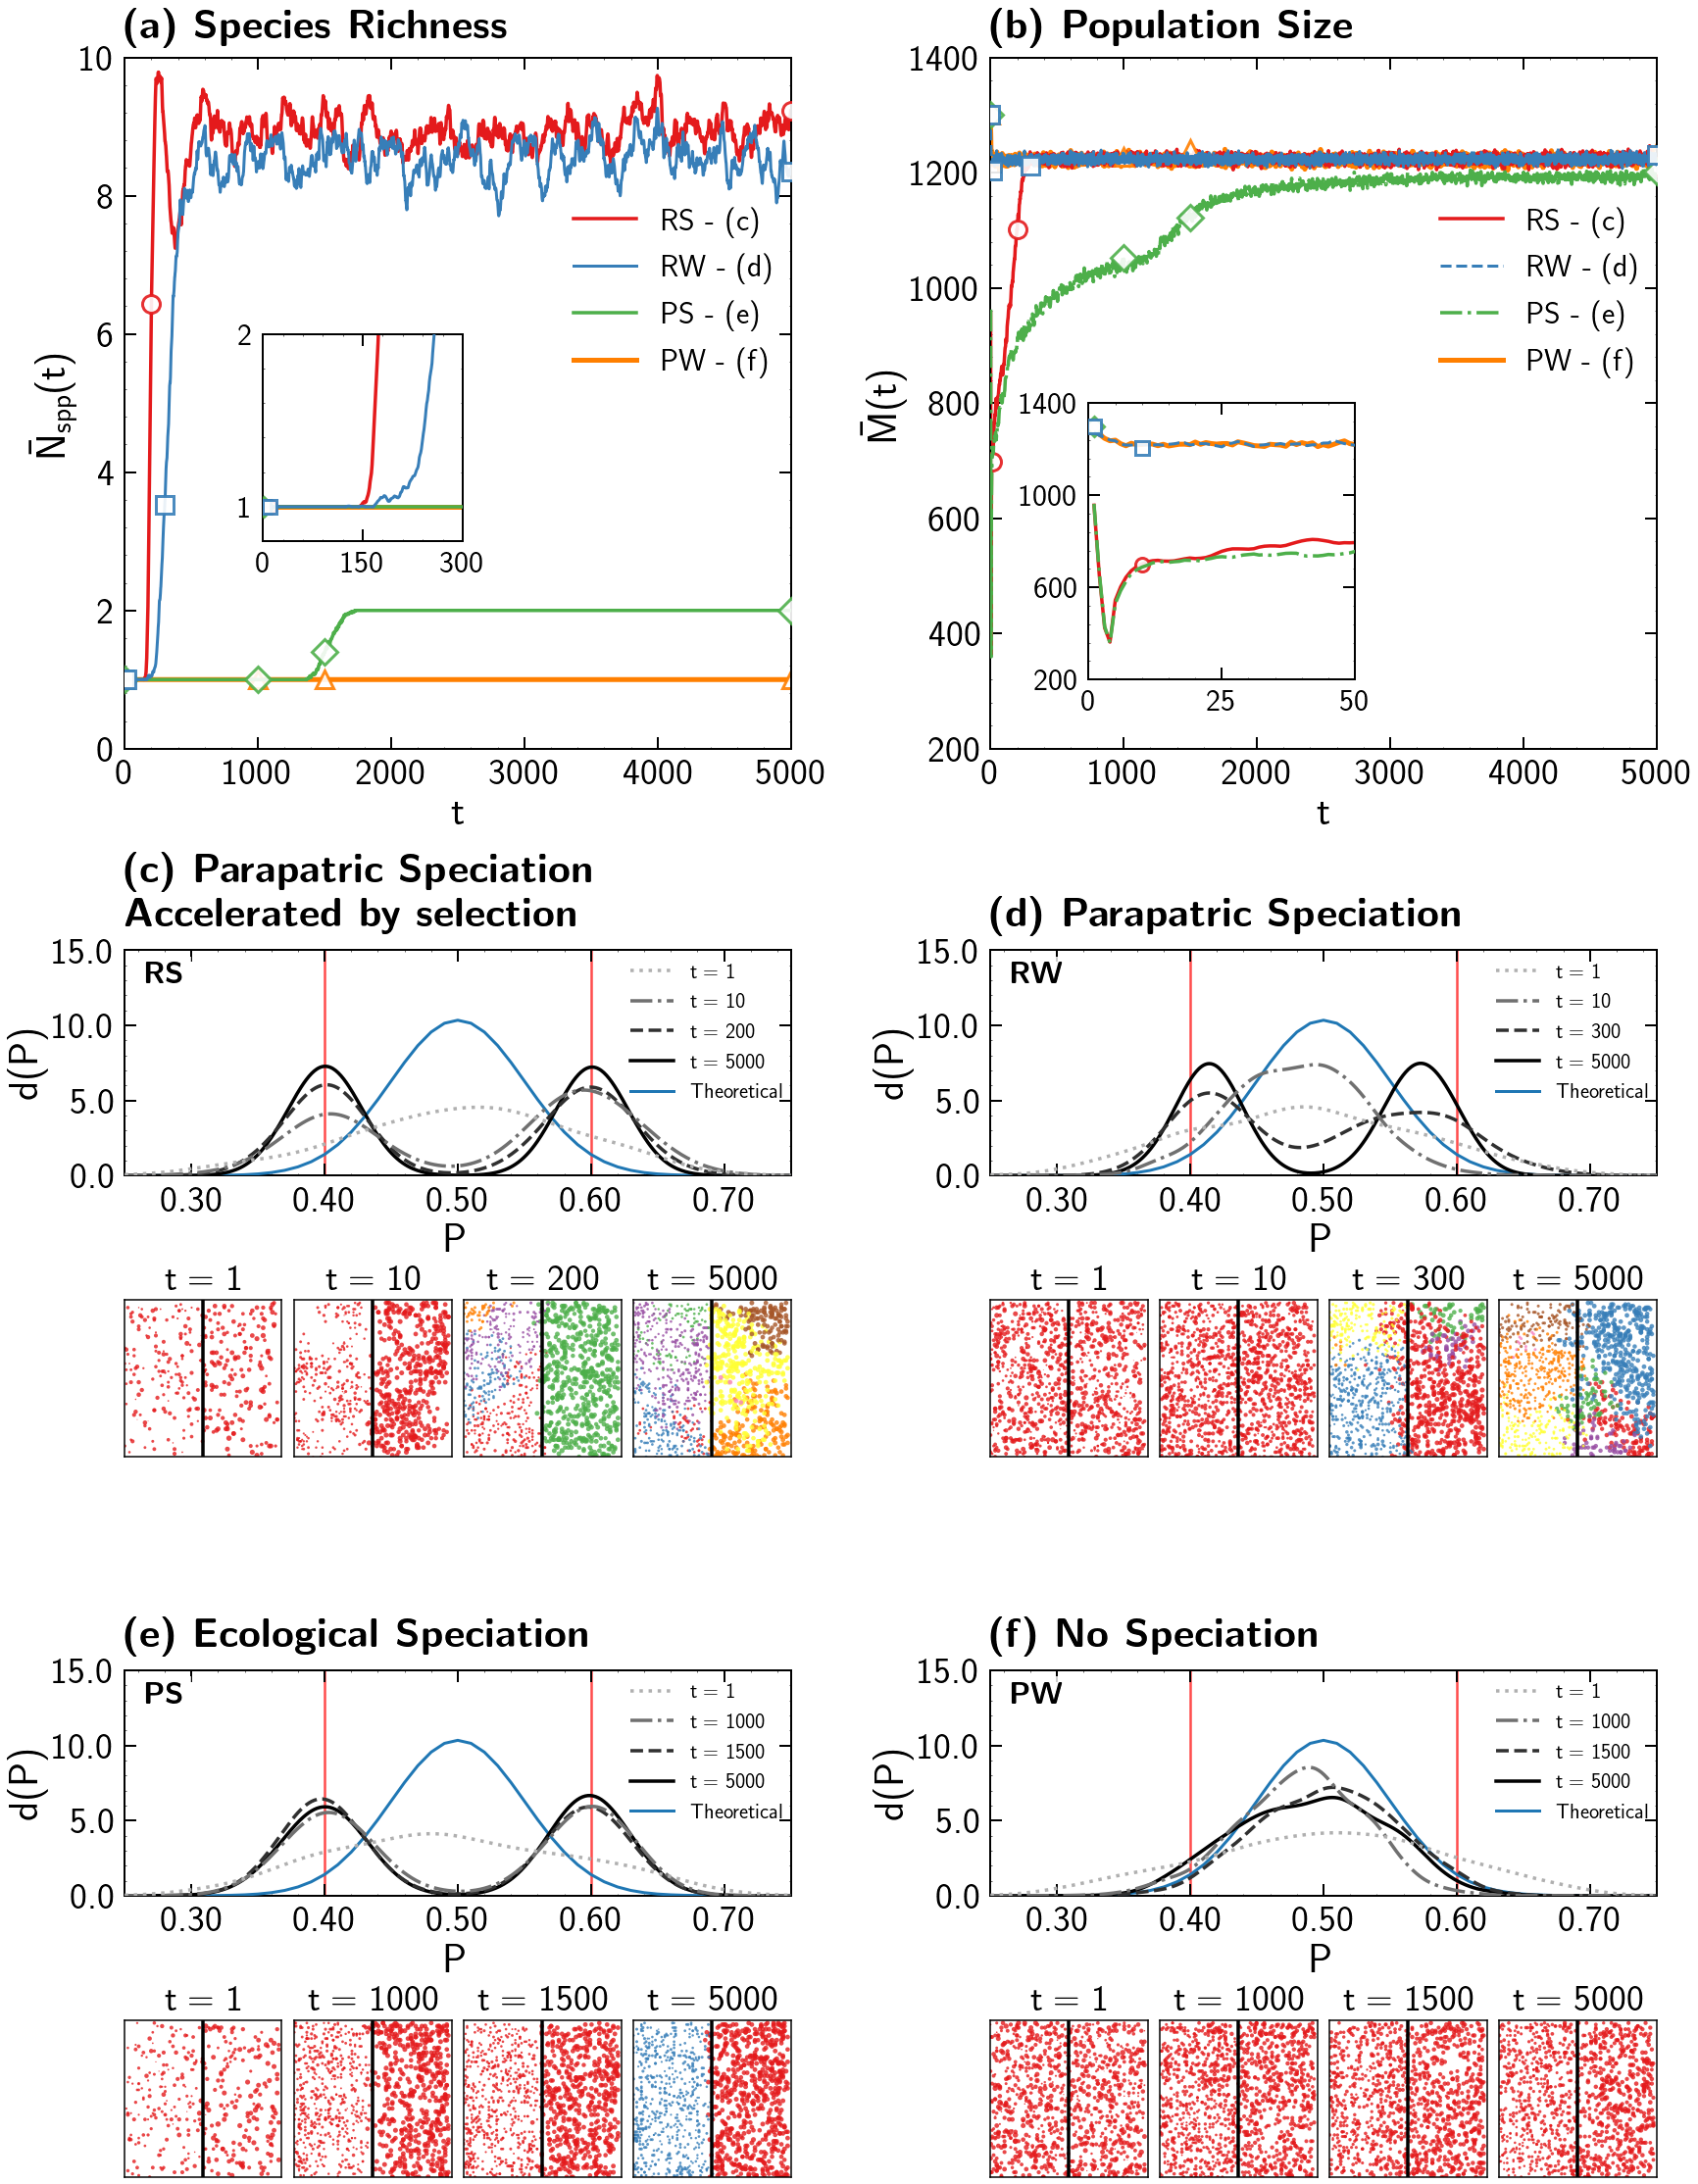

In [26]:
fig = plt.figure(figsize=(28, 40))

gs_main = gridspec.GridSpec(3, 2, height_ratios=[2.0, 1.5, 1.5], hspace=0.35, wspace=0.30)
fig.subplots_adjust(hspace=0.2)

ax_a = fig.add_subplot(gs_main[0, 0])
draw_panel_a(ax_a)

ax_b = fig.add_subplot(gs_main[0, 1])
draw_panel_b(ax_b)

panel_mapping = [
    (1, 0, 'c', r'G = 0.05B, $\sigma_e$ = 0.05'),
    (1, 1, 'd', r'G = 0.05B, $\sigma_e$ = 0.40'),
    (2, 0, 'e', r'G = 0.30B, $\sigma_e$ = 0.05'),
    (2, 1, 'f', r'G = 0.30B, $\sigma_e$ = 0.40')
]

for row, col, letter, label_key in panel_mapping:
    gs_sub = gs_main[row, col].subgridspec(2, 4, height_ratios=[2.0, 1.5], hspace=0.63, wspace=0.08)
    
    ax_kde = fig.add_subplot(gs_sub[0, :])
    
    draw_kde(ax_kde, letter, label_key, dirs[label_key])
    
    ax_snaps = [fig.add_subplot(gs_sub[1, i]) for i in range(4)]
    draw_spatial(ax_snaps, label_key, dirs[label_key])
    
plt.savefig('fig3-opt2.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Homogeneous scenario

In [13]:
def draw_panel_a(ax):
    ax_ins = inset_axes(ax, width="30%", height="30%", loc='center left', 
                        bbox_to_anchor=(0.20, -0.1, 1, 1), 
                        bbox_transform=ax.transAxes)
    
    for label, path in dirs.items():
        t, m = load_and_average(path, 'SpeciesCount')
        if t is None: continue
        cfg = styles[label]
        y_smooth = smooth_data(m)
        
        for a in [ax, ax_ins]:
            a.plot(t, y_smooth, lw=cfg['lw'], color=cfg['c'], label=legend_labels[label] if a==ax else "", zorder=cfg['z'])
            
            m_times = [tp for tp in h_times[label] if tp in t]
            m_vals = [y_smooth[np.where(t==tp)[0][0]] for tp in m_times]
            a.plot(m_times, m_vals, ls='None', marker=cfg['m'], ms=18 if a==ax else 14, 
                   mfc='white', mec=cfg['c'], mew=3.0, alpha=0.9, zorder=cfg['z']+1)
            
    format_ax(ax, major_size=SIZE_TICK)
    format_ax(ax_ins, major_size=SIZE_INSET_TICK)
    ax.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL)
    ax.set_ylabel(r'$\mathsf{\bar{N}_{\mathrm{spp}}(t)}$', fontsize=SIZE_LABEL)
    ax.set_xlim(0, 5000); ax.set_ylim(0, 10)
    
    ax_ins.set_xlim(0, 300); ax_ins.set_ylim(0.8, 2.0)
    ax_ins.set_yticks([1, 2]); ax_ins.set_xticks([0, 150, 300])
    
    ax.legend(loc='center right', bbox_to_anchor=(1.02, 0.66), frameon=False, fontsize=SIZE_LEGEND)
    ax.set_title(r'\textbf{\textsf{(a) Species Richness}}', loc='left', fontsize=SIZE_TITLE, pad=20)    
    
def draw_panel_b(ax):
    ax_ins = inset_axes(ax, width="40%", height="40%", loc='center left', 
                        bbox_to_anchor=(0.14, -0.2, 1, 1), 
                        bbox_transform=ax.transAxes)
    
  
    for label, path in dirs.items():
        t, m = load_and_average(path, 'PopulationSize', num_files=50)
        if t is None: continue
        
        m[0] = 1300 
        m_smooth = smooth_data(m, window=7, poly=2) 
        cfg = styles[label]
        
        for a in [ax, ax_ins]:
            a.plot(t, m_smooth, color=cfg['c'], linestyle=cfg['ls'], linewidth=cfg['lw'], 
                   label=legend_labels[label] if a==ax else "", zorder=cfg['z'])
            
            m_times = [tp for tp in h_times[label] if tp in t]
            m_vals = [m[np.where(t==tp)[0][0]] for tp in m_times]
            
            a.plot(m_times, m_vals, ls='None', marker=cfg['m'], ms=18 if a==ax else 14, 
                   mfc='white', mec=cfg['c'], mew=3.0, alpha=0.9, zorder=cfg['z']+1)
  

    format_ax(ax, major_size=SIZE_TICK, is_int=True)
    format_ax(ax_ins, major_size=SIZE_INSET_TICK, is_int=True)

    ax.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL)
    ax.set_ylabel(r'$\mathsf{\bar{M}(t)}$', fontsize=SIZE_LABEL)
    
    ax.set_xlim(0, 5000); ax.set_ylim(200, 1400)
    
    ax_ins.set_xlim(0, 50); ax_ins.set_ylim(200, 1400)
    ax_ins.set_yticks([200, 600,1000, 1400])
    
    ax.legend(loc='center right', bbox_to_anchor=(1.02, 0.66), frameon=False, fontsize=SIZE_LEGEND)
    ax.set_title(r'\textbf{\textsf{(b) Population Size}}', loc='left', fontsize=SIZE_TITLE, pad=20)    
          
        
def draw_kde(ax, letter, label_key, path):
    times = h_times[label_key]
    colors = ['#B0B0B0', '#707070', '#303030', '#000000']
    ls = [':', '-.', '--', '-']
    dir_all = os.path.join(path, 'All')

    for i, t in enumerate(times):
        file = os.path.join(dir_all, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep=r'\s+', header=None, names=['id','x','y','sp','deg','phenotype','fit'])
            pheno = df['phenotype'].dropna().values
            if len(pheno) > 1:
                kde = gaussian_kde(pheno)
                x_range = np.linspace(0.25, 0.75, 500)
                ax.plot(x_range, kde(x_range), color=colors[i], linestyle=ls[i], lw=3.5, 
                        label=fr'$\mathsf{{t = {t}}}$', zorder=10-i)
        except Exception: 
            pass

    if x_theo is not None:
        ax.plot(x_theo, y_theo, color='#1f77b4', linestyle='-', lw=3.0, label=r'$\mathsf{Theoretical}$', zorder=5)

    for p in [0.5]: 
        ax.axvline(p, color='red', lw=2.5, alpha=0.7, zorder=1)

    ax.set_xlim(0.25, 0.75)
    ax.set_ylim(0, 15.0) 
    ax.set_xlabel(r'$\mathsf{P}$', fontsize=SIZE_LABEL, labelpad=5)
    ax.set_ylabel(r'$\mathsf{d(P)}$', fontsize=SIZE_LABEL, labelpad=5)
    ax.set_yticks(np.arange(0, 45.1, 15.0))
    
    format_ax(ax, major_size=SIZE_TICK)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.2f}$'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.1f}$'))
    
    ax.legend(fontsize=SIZE_LEGEND_KDE, loc="upper right", frameon=False, ncol=1, bbox_to_anchor=(1.02, 1.03))
    
    desc = panel_descriptions[letter]
    
    if letter == 'c':
        linha1 = rf'\textbf{{\textsf{{\fontsize{{42}}{{48}}\selectfont (c) {desc["text"]}}}}}'
        title_text = f'{linha1}'
    else:
        title_text = rf'\textbf{{\textsf{{\fontsize{{42}}{{48}}\selectfont ({letter}) {desc["text"]}}}}}'
        
    ax.set_title(title_text, loc='left', pad=25)
    ax.text(0.03, 0.95, rf'\textbf{{\textsf{{{desc["params"]}}}}}', 
            transform=ax.transAxes, fontsize=SIZE_LEGEND, 
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5), zorder=15)

def draw_spatial(axes_list, label_key, path):
    times = h_times[label_key]
    dir_all = os.path.join(path, 'All')
    cmap_sp = plt.get_cmap('Set1')

    for i, t in enumerate(times):
        ax = axes_list[i]
        file = os.path.join(dir_all, f"data{t}.dat")
        try:
            df = pd.read_csv(file, sep=r'\s+', header=None, names=['id', 'x', 'y', 'sp', 'deg', 'pheno', 'fit'])
            if not df.empty:
                sizes = (((df['pheno'] - 0.4) / 0.2) * 10 + 5) * 1.5
                unique_spp = sorted(df['sp'].unique())
                color_dict = {sp: cmap_sp(idx % cmap_sp.N) for idx, sp in enumerate(unique_spp)}
                colors = df['sp'].map(color_dict)
                ax.scatter(df['x'], df['y'], color=colors, s=sizes, alpha=0.8, edgecolors='none')
        except Exception: 
            pass

        ax.set_xlim(0, 101)
        ax.set_ylim(0, 101)
        ax.set_aspect('equal')
        ax.set_anchor('N')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values(): 
            spine.set_linewidth(1.5)
        
        ax.set_title(fr'$\mathsf{{t = {t}}}$', fontsize=SIZE_SPATIAL_TITLE, pad=10)

/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/lara/.local/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


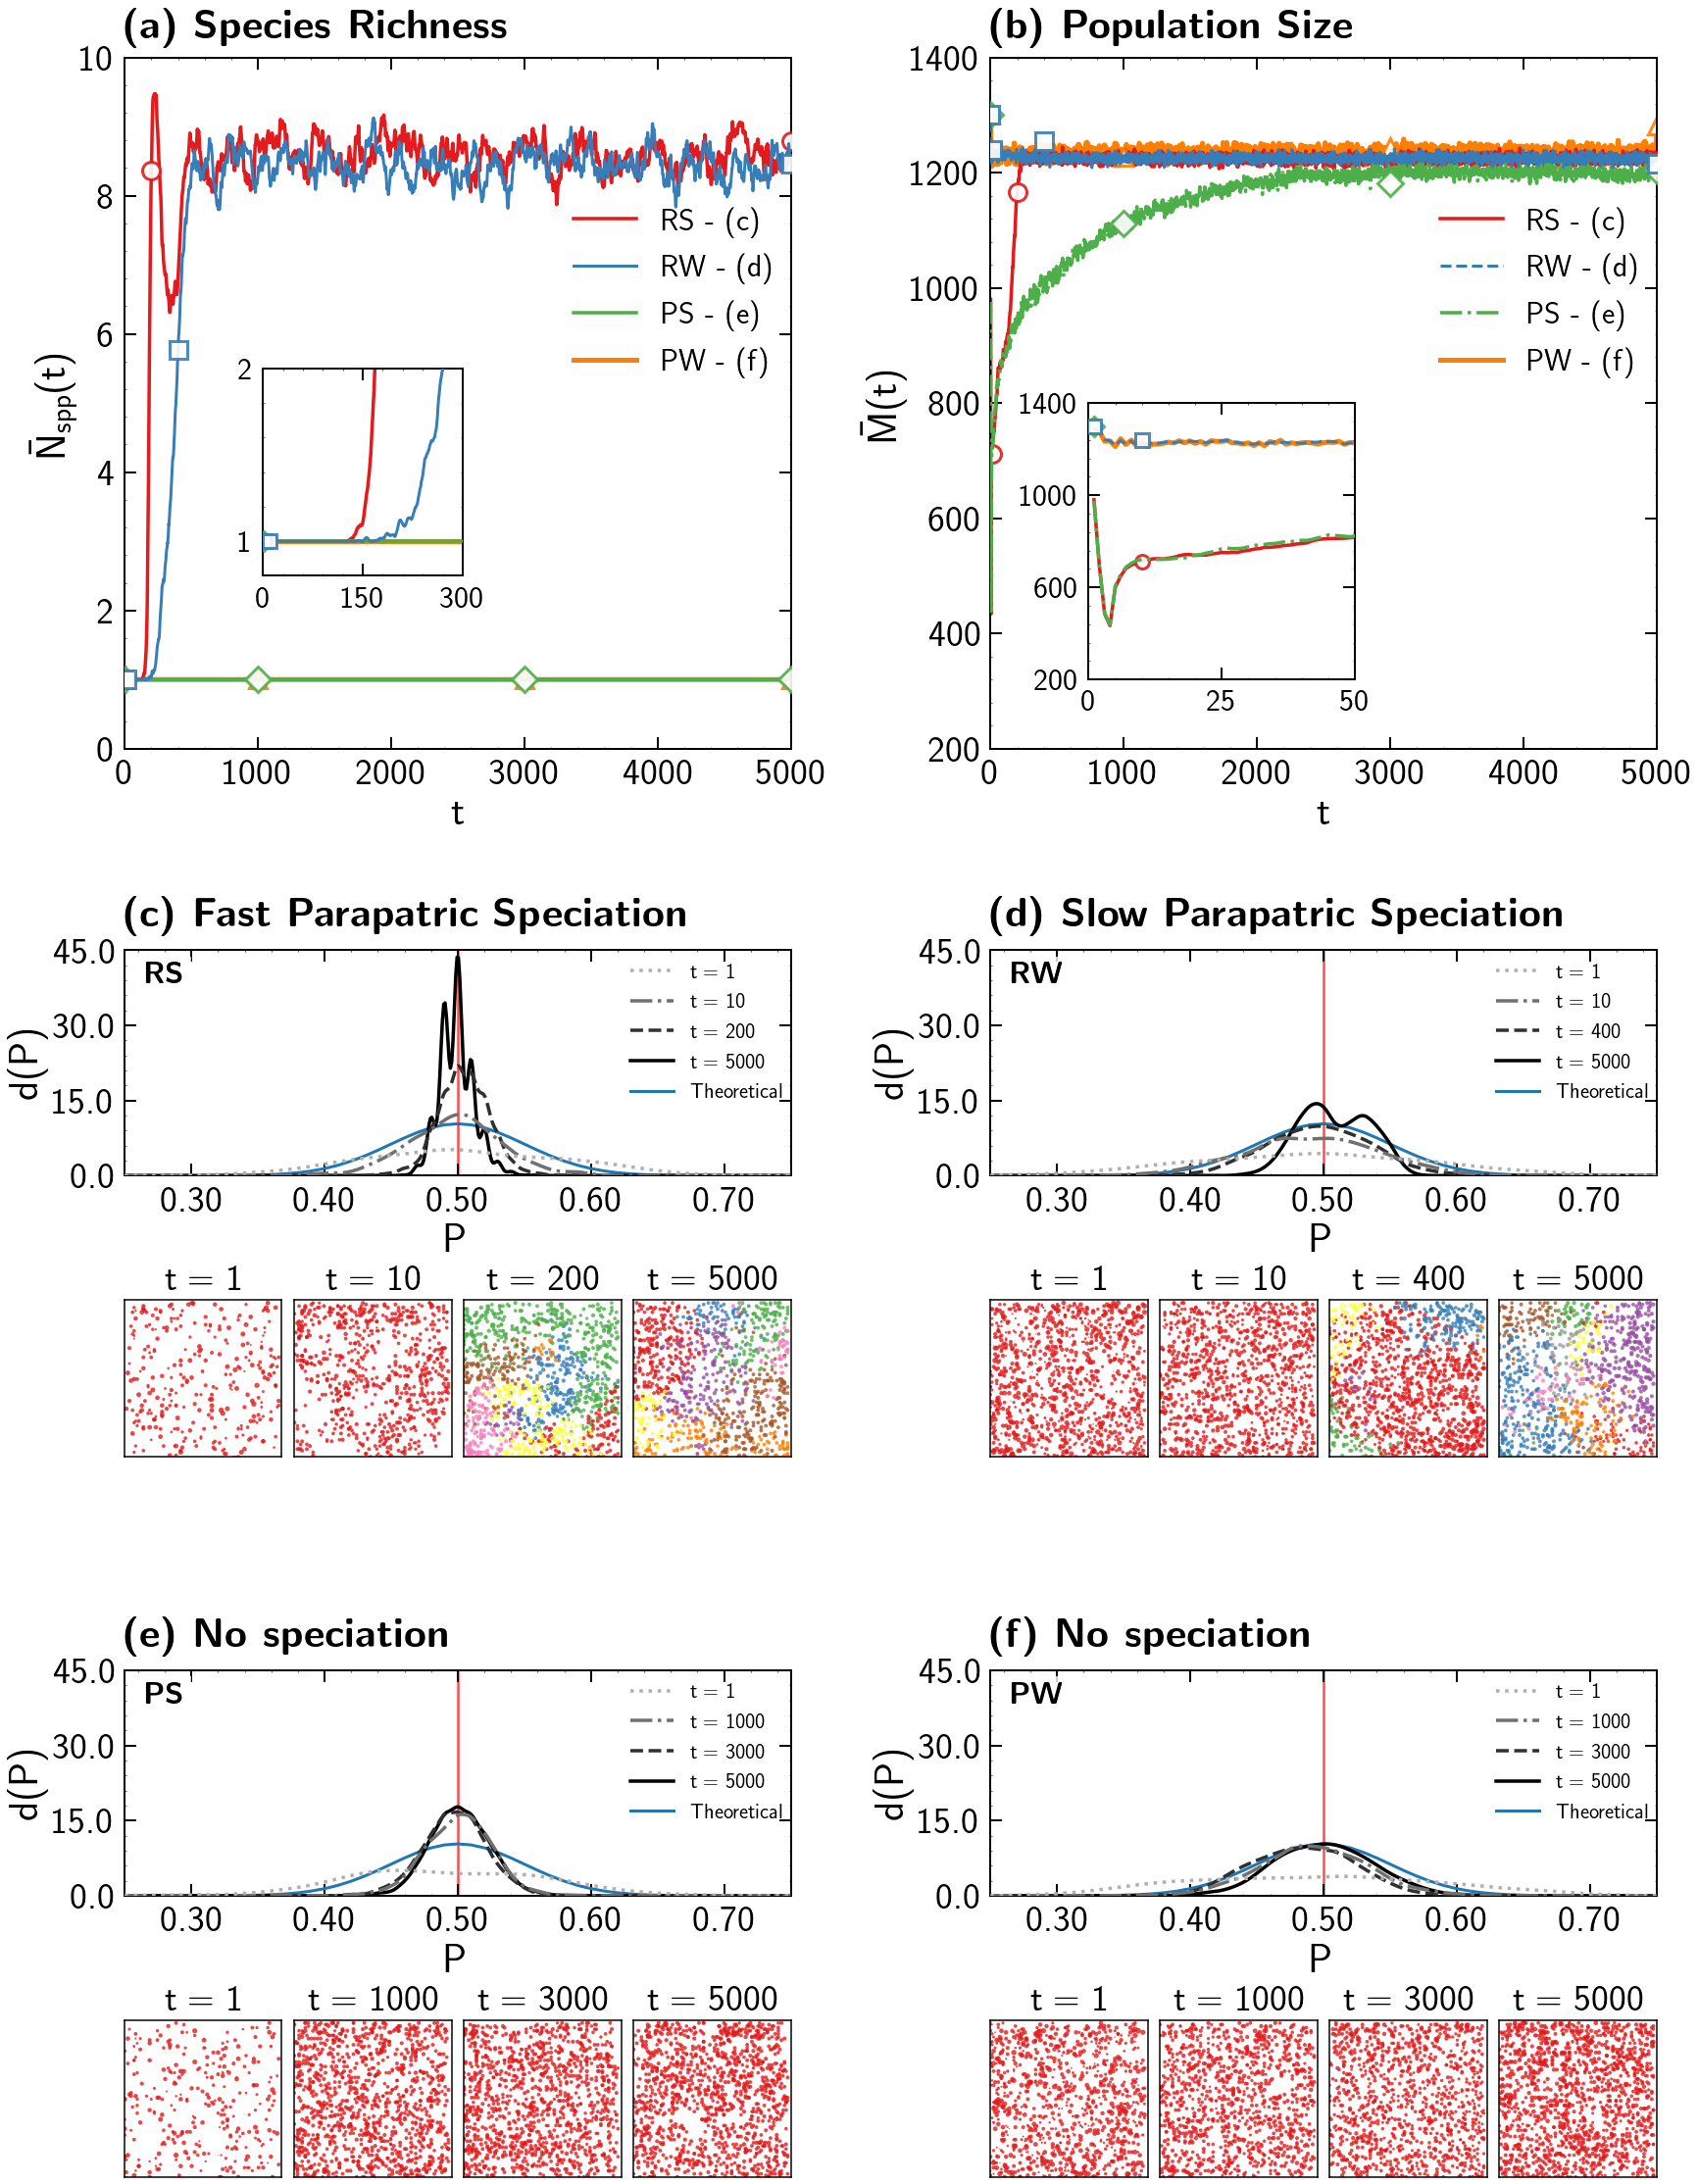

In [12]:
fig = plt.figure(figsize=(28, 40))

gs_main = gridspec.GridSpec(3, 2, height_ratios=[2.0, 1.5, 1.5], hspace=0.35, wspace=0.30)
fig.subplots_adjust(hspace=0.2)

ax_a = fig.add_subplot(gs_main[0, 0])
draw_panel_a(ax_a)

ax_b = fig.add_subplot(gs_main[0, 1])
draw_panel_b(ax_b)

panel_mapping = [
    (1, 0, 'c', r'G = 0.05B, $\sigma_e$ = 0.05'),
    (1, 1, 'd', r'G = 0.05B, $\sigma_e$ = 0.40'),
    (2, 0, 'e', r'G = 0.30B, $\sigma_e$ = 0.05'),
    (2, 1, 'f', r'G = 0.30B, $\sigma_e$ = 0.40')
]

for row, col, letter, label_key in panel_mapping:
    gs_sub = gs_main[row, col].subgridspec(2, 4, height_ratios=[2.0, 1.5], hspace=0.63, wspace=0.08)
    
    ax_kde = fig.add_subplot(gs_sub[0, :])
    
    draw_kde(ax_kde, letter, label_key, dirs[label_key])
    
    ax_snaps = [fig.add_subplot(gs_sub[1, i]) for i in range(4)]
    draw_spatial(ax_snaps, label_key, dirs[label_key])
    
plt.savefig('fig3-opt2.pdf', bbox_inches='tight', dpi=300)
plt.show()

# PHENOTYPIC DISTRIBUTION FOR G = 0.05B, sigma_e = 0.40

In [38]:
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': (
        r'\usepackage{sfmath} '
        r'\renewcommand{\familydefault}{\sfdefault} '
        r'\normalfont'
    ),
})




In [39]:
def calculate_manual_profile(data, x_range, h=0.015):
    n = len(data)
    final_curve = np.zeros_like(x_range)

    for point in data:
        z = (x_range - point) / h

        gaussian = (1.0 / (h * np.sqrt(2 * np.pi))) * np.exp(-0.5 * z**2)

        final_curve += gaussian

    return final_curve / n


def generate_evolution_plot(base_directory):

    timepoints = [
        1, 10, 100, 200, 500,
        1000, 2000, 3000, 4000, 5000,
        6000, 7000, 8000, 9000, 10000
    ]

    ncols = 5
    nrows = 3

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(42, 32)
    )

    axes_flat = axes.flatten()

    cmap = plt.get_cmap('turbo')


    TITLE_SIZE = 70
    AXIS_LABEL_SIZE = 65
    TICK_SIZE = 60
    LEGEND_SIZE = 85

    # ---------------------------------------------------------
    # Plot limits
    # ---------------------------------------------------------

    p_min = 0.3
    p_max = 0.7

    global_y_limit = 300

    bin_width = (p_max - p_min) / 30

    # ---------------------------------------------------------
    # Panels
    # ---------------------------------------------------------

    for i, t in enumerate(timepoints):

        ax = axes_flat[i]

        file_path = os.path.join(
            base_directory,
            f"data{t}.dat"
        )

        # -----------------------------------------------------
        # Read data and plot histogram + KDE
        # -----------------------------------------------------

        if os.path.exists(file_path):

            try:

                df = pd.read_csv(
                    file_path,
                    sep=r'\s+',
                    header=None,
                    names=[
                        'id',
                        'x',
                        'y',
                        'species',
                        'deg',
                        'phenotype',
                        'fit'
                    ]
                )

                # -------------------------------------------------
                # Histogram separated by species
                # -------------------------------------------------

                species_list = df['species'].unique()

                data_per_species = [
                    df[df['species'] == s]['phenotype']
                    for s in species_list
                ]

                colors = [
                    cmap(val)
                    for val in np.linspace(
                        0,
                        1,
                        len(species_list)
                    )
                ]

                ax.hist(
                    data_per_species,
                    bins=30,
                    range=(p_min, p_max),
                    stacked=True,
                    color=colors,
                    edgecolor='none',
                    alpha=0.8,
                    zorder=2
                )

                # -------------------------------------------------
                # KDE / phenotype profile
                # -------------------------------------------------

                phenotypes = df['phenotype'].values

                if len(phenotypes) > 1:

                    x_range = np.linspace(
                        p_min,
                        p_max,
                        250
                    )

                    y_final = (
                        calculate_manual_profile(
                            phenotypes,
                            x_range,
                            h=0.015
                        )
                        * len(phenotypes)
                        * bin_width
                    )

                    ax.plot(
                        x_range,
                        y_final,
                        color='black',
                        linewidth=8,
                        zorder=10
                    )

            except Exception as e:

                print(
                    f"Error processing time {t}: {e}"
                )

        # -----------------------------------------------------
        # Environmental optima / reference phenotype
        # -----------------------------------------------------

        ax.axvline(
            0.4,
            color='#0000FF',
            linestyle='--',
            linewidth=6,
            alpha=0.6,
            zorder=1
        )

        ax.axvline(
            0.5,
            color='black',
            linestyle='--',
            linewidth=6,
            alpha=0.4,
            zorder=1
        )

        ax.axvline(
            0.6,
            color='#FF0000',
            linestyle='--',
            linewidth=6,
            alpha=0.6,
            zorder=1
        )

    

        ax.set_title(
            rf"$\mathsf{{t = {t}}}$",
            fontsize=TITLE_SIZE,
            pad=45
        )

     

        ax.set_xticks([
            0.4,
            0.5,
            0.6
        ])

        ax.set_xticklabels([
            r'$\mathsf{0.4}$',
            r'$\mathsf{0.5}$',
            r'$\mathsf{0.6}$'
        ],
            fontsize=TICK_SIZE
        )

        ax.set_xlabel(
            r'$\mathsf{P}$',
            fontsize=AXIS_LABEL_SIZE,
            labelpad=25
        )

    
        ax.set_yticks([
            0,
            150,
            300
        ])

        if i % ncols == 0:

            ax.set_yticklabels([
                r'$\mathsf{0}$',
                r'$\mathsf{150}$',
                r'$\mathsf{300}$'
            ],
                fontsize=TICK_SIZE
            )

            ax.set_ylabel(
                r'$\mathsf{Abundance}$',
                fontsize=AXIS_LABEL_SIZE,
                labelpad=35
            )

        else:

            ax.set_yticklabels([])

     

        ax.tick_params(
            axis='both',
            which='major',
            direction='in',
            width=5,
            length=20,
            pad=20
        )

        # -----------------------------------------------------
        # Limits
        # -----------------------------------------------------

        ax.set_xlim(
            p_min,
            p_max
        )

        ax.set_ylim(
            0,
            global_y_limit
        )

        # -----------------------------------------------------
        # Axes style
        # -----------------------------------------------------

        for spine in ax.spines.values():
            spine.set_linewidth(5)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # =========================================================
    # Legend
    # =========================================================

    legend_elements = [

        Line2D(
            [0],
            [0],
            color='#0000FF',
            linestyle='--',
            linewidth=8,
            alpha=0.6,
            label=r'$\mathsf{P = 0.4}$'
        ),

        Line2D(
            [0],
            [0],
            color='black',
            linestyle='--',
            linewidth=8,
            alpha=0.4,
            label=r'$\mathsf{P = 0.5}$'
        ),

        Line2D(
            [0],
            [0],
            color='#FF0000',
            linestyle='--',
            linewidth=8,
            alpha=0.6,
            label=r'$\mathsf{P = 0.6}$'
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        fontsize=LEGEND_SIZE,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    # =========================================================
    # Spacing
    # =========================================================

    plt.subplots_adjust(
        left=0.08,
        right=0.97,
        bottom=0.08,
        top=0.92,
        hspace=0.6,
        wspace=0.3
    )

    # =========================================================
    # Save
    # =========================================================

    plt.savefig(
        "phenotype_evolution_grid.pdf",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()




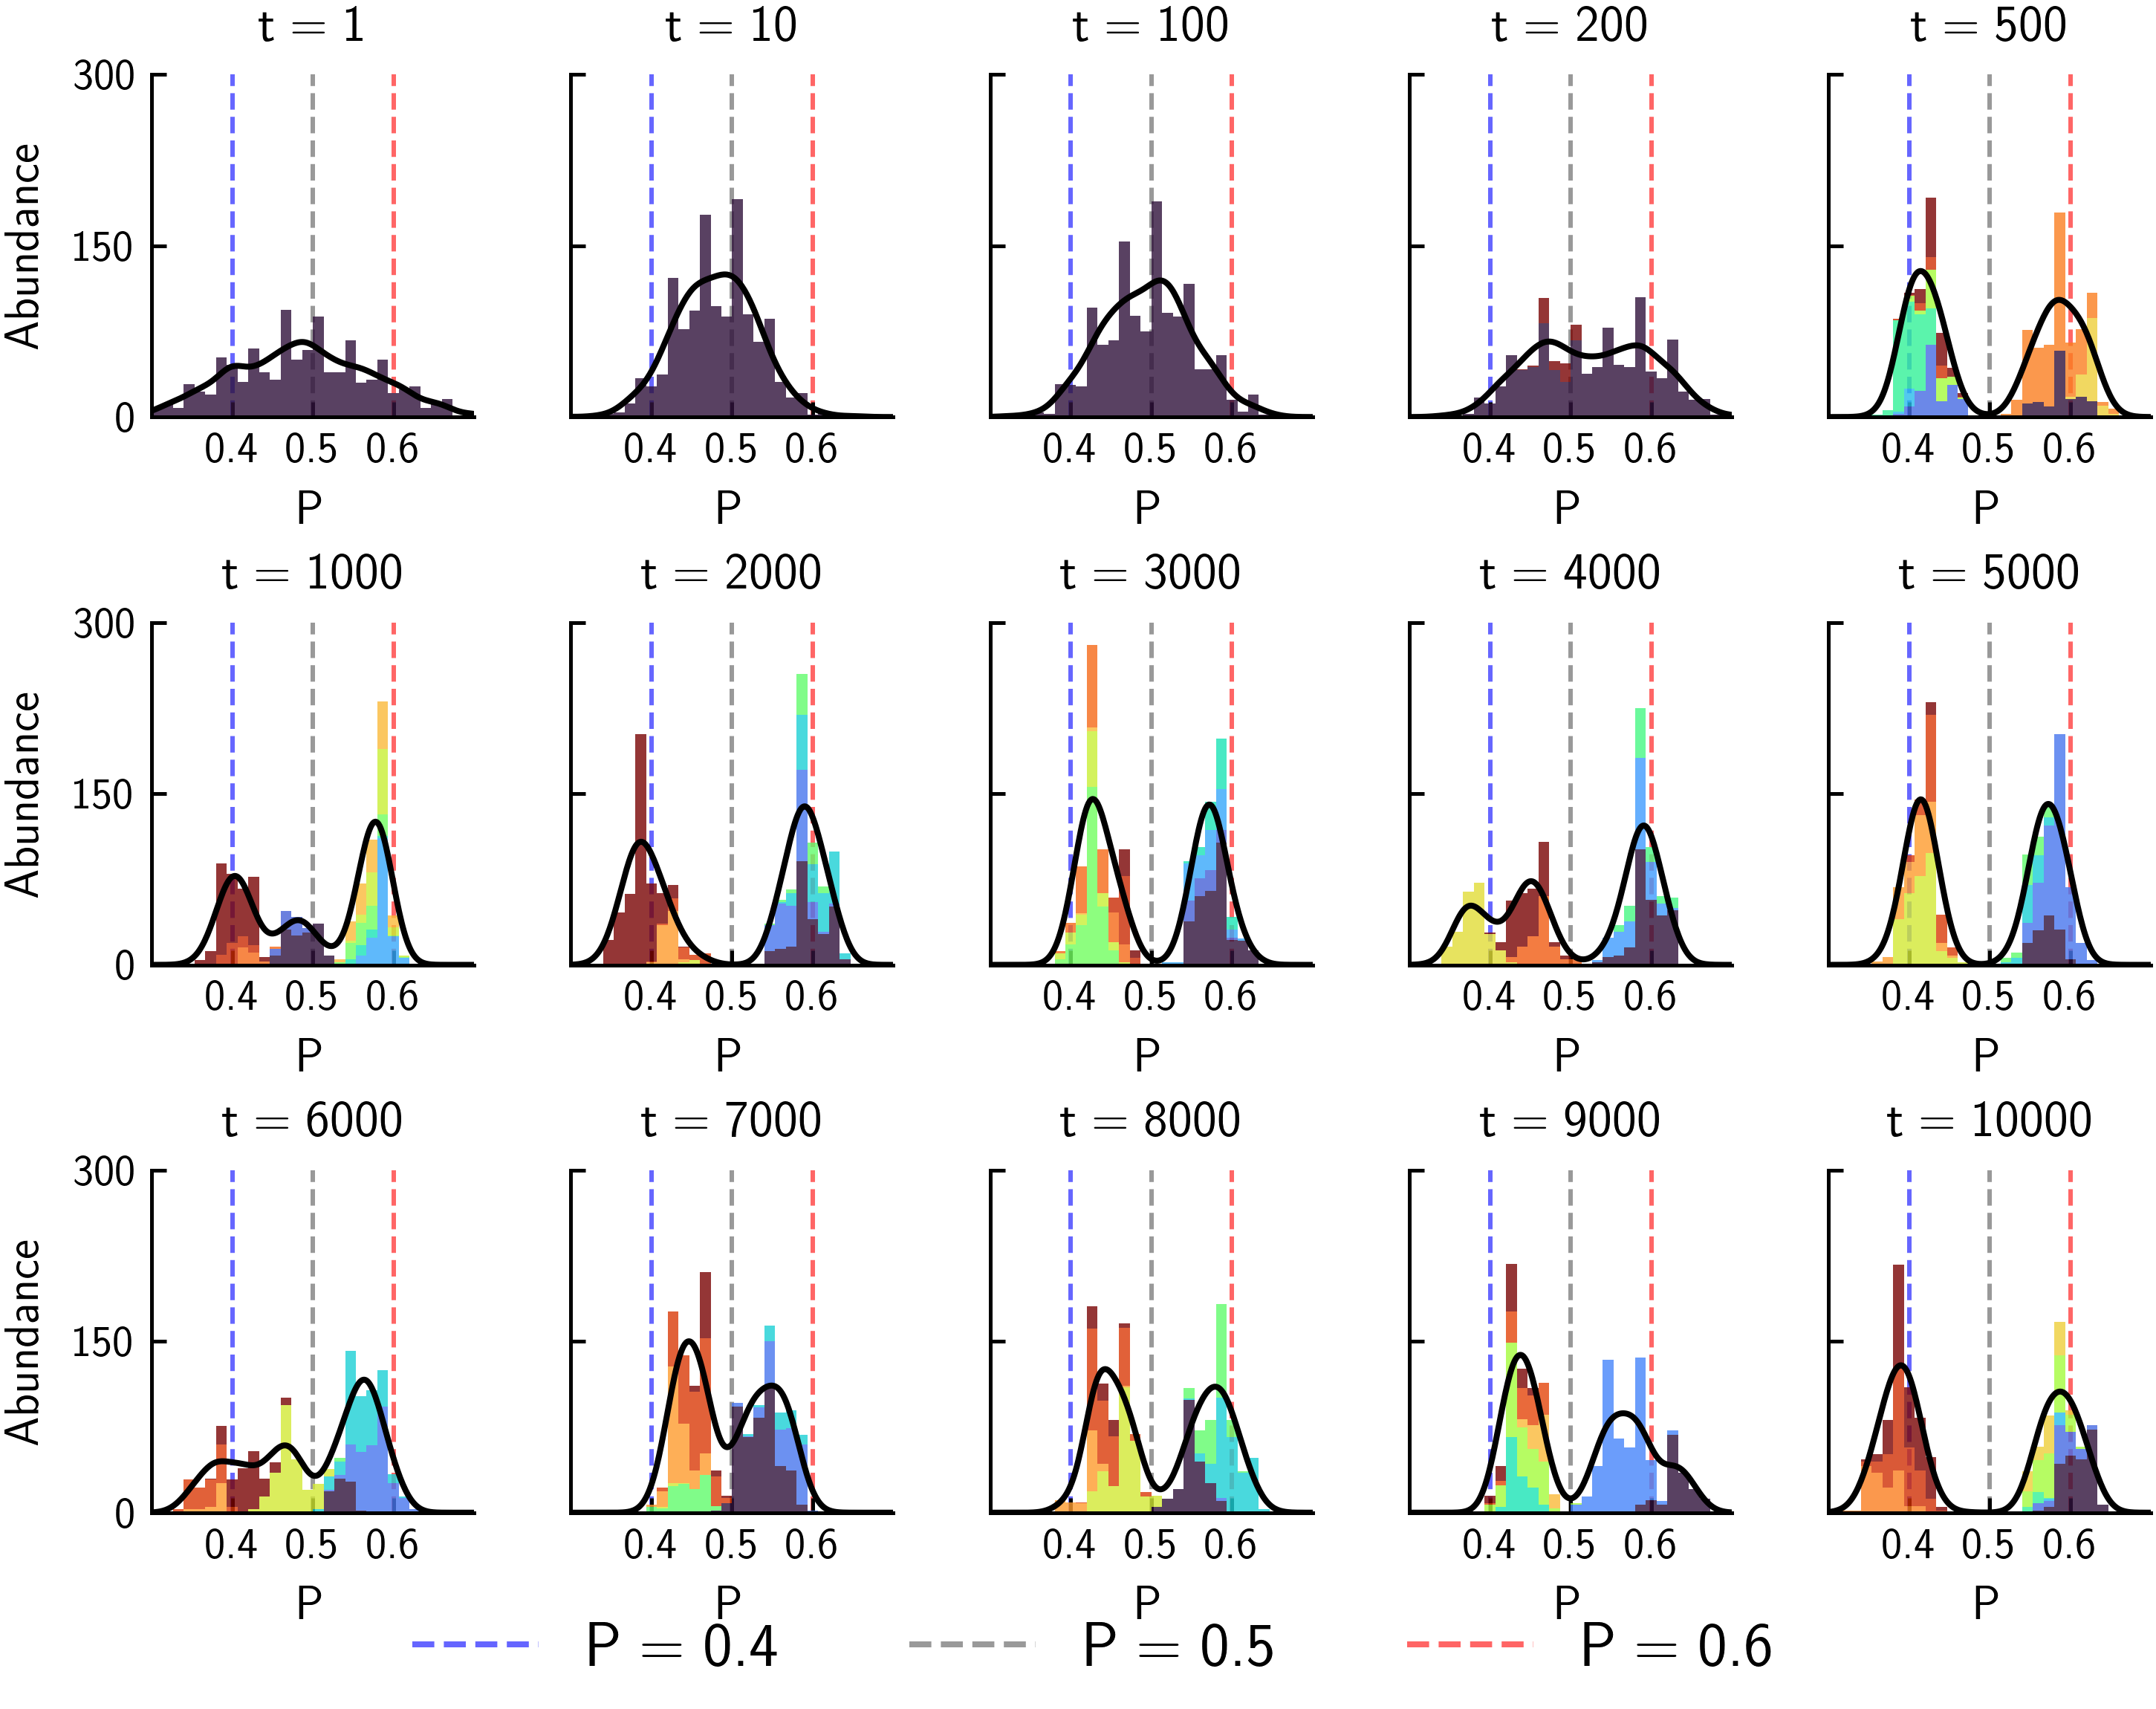

In [40]:
base_directory = "DATA/heterogeneous/G5sigma40/All"

generate_evolution_plot(base_directory)

# GEOGRAPHIC DISTANCE VS GENETIC DISTANCE

In [45]:
from scipy.spatial.distance import pdist
import seaborn as sns
from scipy.spatial.distance import cdist
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator
import glob

warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

In [46]:
def plot_ibd_analysis(scenarios, sample_rate=1.0):
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    letters = ['a', 'b', 'c', 'd']

    for i, (label, config) in enumerate(scenarios.items()):
        if i >= len(axes): break
        ax = axes[i]
        folder = config['path']
        
        spatial_file = os.path.join(folder, 'All/data.dat')
        genome_file = os.path.join(folder, 'Genome/genome.dat')
        
        if not (os.path.exists(spatial_file) and os.path.exists(genome_file)):
            ax.text(0.5, 0.5, f"Missing Data:\n{label}", transform=ax.transAxes, ha='center', color='red', fontsize=20)
            continue

        print(f"Processing: {label}...")
        
        df = pd.read_csv(spatial_file, delim_whitespace=True, header=None,
                         names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
        
        with open(genome_file, 'r') as f:
            all_lines = [line.strip() for line in f if line.strip()]
        
        min_size = min(len(df), len(all_lines))
        df = df.iloc[:min_size]
        all_lines = all_lines[:min_size]

        sample_size = max(2, int(min_size * sample_rate))
        idx = np.random.choice(min_size, sample_size, replace=False)
        
        df_sub = df.iloc[idx].reset_index(drop=True)
        genomes = np.array([np.array(list(all_lines[j]), dtype=int) for j in idx])

        dist_geo = pdist(df_sub[['x', 'y']].values, metric='euclidean')
        dist_gen = pdist(genomes, metric='hamming')
        
        species_ids = df_sub['species'].values
      
        matrix_comparison = (species_ids[:, None] == species_ids)
        intra_mask = matrix_comparison[np.triu_indices(len(species_ids), k=1)]
        inter_mask = ~intra_mask 

        if np.any(inter_mask):
            ax.scatter(dist_geo[inter_mask], dist_gen[inter_mask], 
                       color='#999999', alpha=0.4, s=35, label='Interspecies', zorder=1, rasterized=True)

        if np.any(intra_mask):
            ax.scatter(dist_geo[intra_mask], dist_gen[intra_mask], 
                       color=config['color'], alpha=0.4, s=35, label='Intraspecies', zorder=2, rasterized=True)

        def fit_log_line(x_data, y_data, mask, ax, color, style, width, label_prefix, zorder):
            valid = (mask) & (x_data > 0) & (y_data > 0)
            if np.count_nonzero(valid) > 5:
                lx, ly = np.log10(x_data[valid]), np.log10(y_data[valid])
                m, b = np.polyfit(lx, ly, 1)
                x_fit = np.logspace(lx.min(), lx.max(), 100)
                y_fit = 10**(m * np.log10(x_fit) + b)
                ax.plot(x_fit, y_fit, color=color, lw=width, ls=style, 
                        label=f'{label_prefix}: {m:.2f}', zorder=zorder)

        fit_log_line(dist_geo, dist_gen, intra_mask, ax, 'black', '-', 5, 'Slope Intra', 5)
        fit_log_line(dist_geo, dist_gen, np.ones_like(intra_mask, dtype=bool), ax, 'black', '--', 3, 'Slope Total', 4)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1e0, 2e2)
        ax.set_ylim(1e-3, 1.5e0)
        
        ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=24, length=12, width=1.5)
        
        ax.set_xlabel('Geographic Distance', fontsize=28)
        ax.set_ylabel('Genetic Distance', fontsize=28)
        ax.set_title(label, fontsize=30, pad=15)
        ax.legend(fontsize=18, loc='lower right', frameon=False)
        ax.text(0.03, 0.93, letters[i], transform=ax.transAxes, fontsize=45, fontweight='bold')

    plt.tight_layout(pad=4.0)
    plt.savefig('IBD.pdf', dpi=300, bbox_inches='tight')
    plt.show()



Processing: $G = 0.05, \sigma_e = 0.05$...
Processing: $G = 0.05, \sigma_e = 0.40$...
Processing: $G = 0.30, \sigma_e = 0.05$...
Processing: $G = 0.30, \sigma_e = 0.40$...


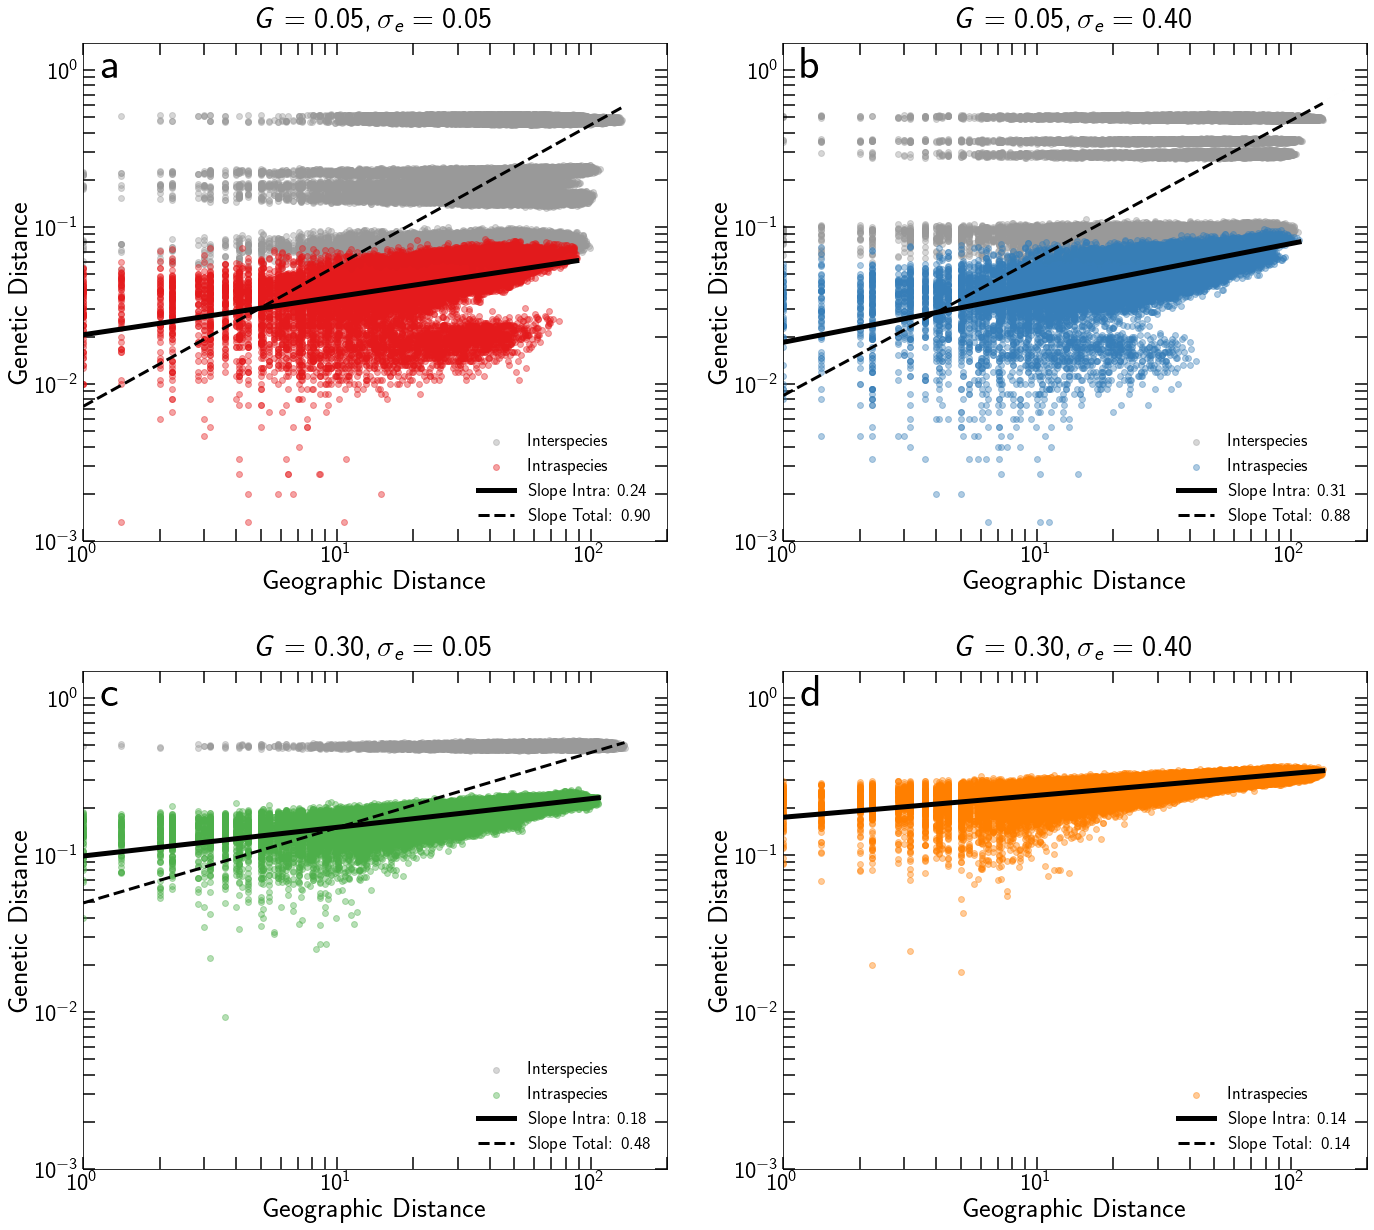

In [47]:
SCENARIOS = {
    r'$G = 0.05, \sigma_e = 0.05$': {'path': 'DATA/phenotype/G5sigma5/', 'color': '#e41a1c'},
    r'$G = 0.05, \sigma_e = 0.40$': {'path': 'DATA/phenotype/G5sigma40/', 'color': '#377eb8'},
    r'$G = 0.30, \sigma_e = 0.05$': {'path': 'DATA/phenotype/G30sigma5/', 'color': '#4daf4a'},
    r'$G = 0.30, \sigma_e = 0.40$': {'path': 'DATA/phenotype/G30sigma40/', 'color': '#ff7f00'}
}

plot_ibd_analysis(SCENARIOS, sample_rate=0.5)



# DEMOGRAPHIC RECOVERY 

# HETEROGENEOUS SCENARIO

In [27]:
SIZE_TITLE = 40        
SIZE_LABEL = 38      
SIZE_TICK = 34         
SIZE_LEGEND = 28       

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})


In [28]:

colunas = ['id', 'x', 'y', 'especie', 'grau', 'fenotipo', 'fitness']

dirs = {
    'RS': 'DATA/heterogeneous/G5sigma5/All/',
    'RW': 'DATA/heterogeneous/G5sigma40/All/',
    'PS': 'DATA/heterogeneous/G30sigma5/All/',
    'PW': 'DATA/heterogeneous/G30sigma40/All/',
}

styles = {
    'RS': {'c': '#e41a1c', 'ls': '-',  'lw': 4.0, 'z': 4}, # Vermelho
    'RW': {'c': '#377eb8', 'ls': '--', 'lw': 4.0, 'z': 3}, # Azul
    'PS': {'c': '#4daf4a', 'ls': '-.', 'lw': 4.0, 'z': 2}, # Verde
    'PW': {'c': '#ff7f00', 'ls': ':',  'lw': 4.5, 'z': 1}, # Laranja
}



In [30]:
def extrair_dinamica_global(pasta, t_max=1000):
    tempos = []
    variancia_fenotipo = []
    fitness_medio = []
    
    for t in range(t_max + 1):
        arquivo = os.path.join(pasta, f'data{t}.dat')
        if not os.path.exists(arquivo):
            continue
            
        try:
            df = pd.read_csv(arquivo, sep=r'\s+', names=colunas, header=None)
            var_fen = df['fenotipo'].var()
            fit_med = df['fitness'].mean()
            
            tempos.append(t)
            variancia_fenotipo.append(var_fen)
            fitness_medio.append(fit_med)
            
        except Exception as e:
            pass 
    return np.array(tempos), np.array(variancia_fenotipo), np.array(fitness_medio)

def format_ax(a, major_size=SIZE_TICK, is_int=False):
    a.tick_params(which='both', direction='in', top=True, right=True)
    a.tick_params(which='major', length=12, width=2.0, labelsize=major_size, pad=10)
    a.xaxis.set_minor_locator(AutoMinorLocator(5))
    a.yaxis.set_minor_locator(AutoMinorLocator(5))
    for spine in a.spines.values(): 
        spine.set_linewidth(2.0)
    fmt = r'$\mathsf{%d}$' if is_int else r'$\mathsf{%g}$'
    a.xaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))
    a.yaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))




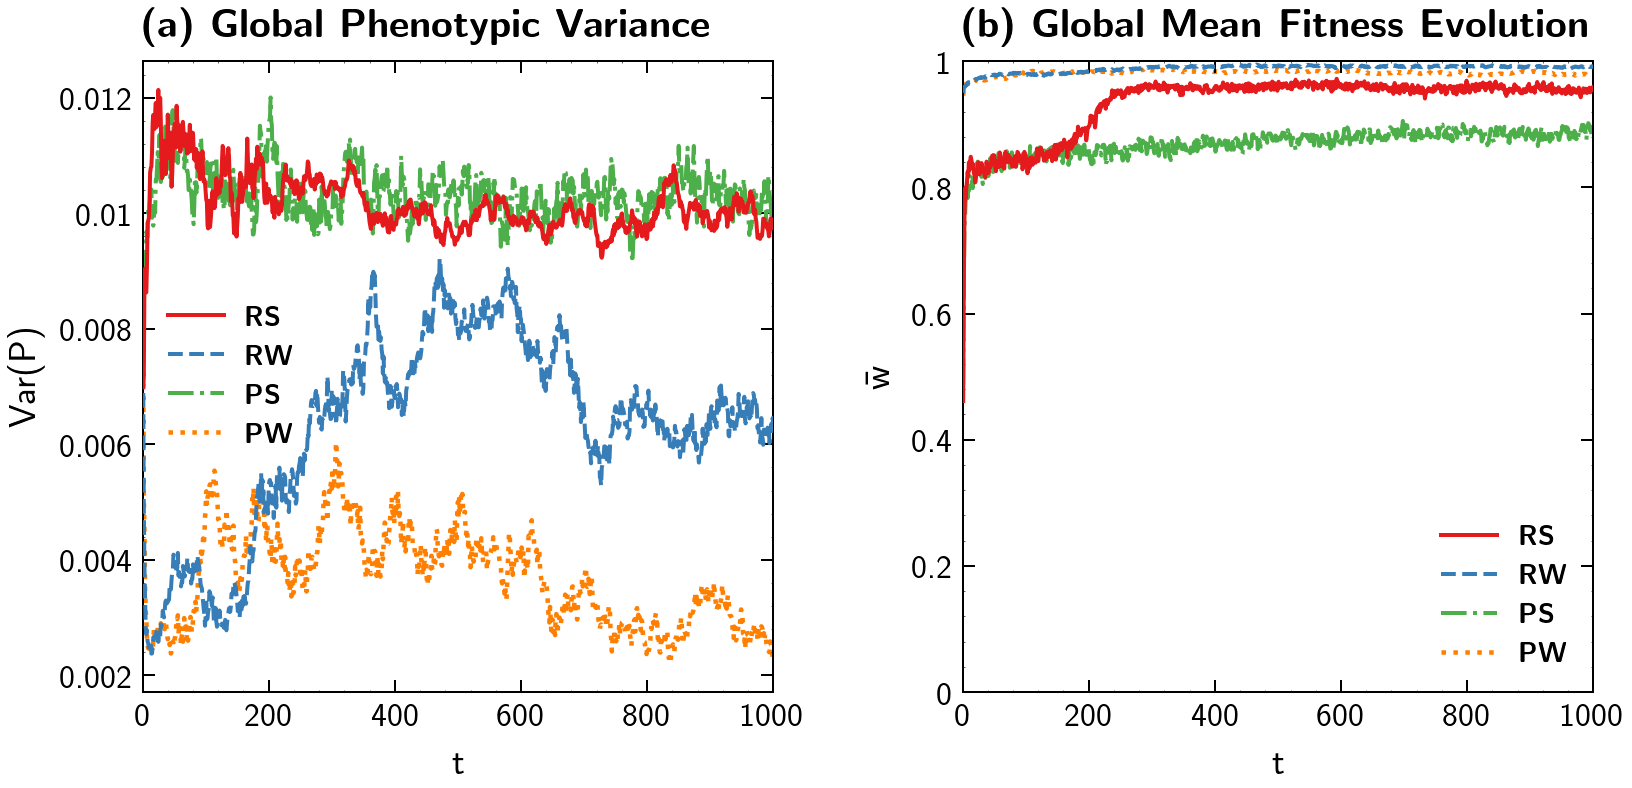

In [31]:
dados_extraidos = {}

for label, pasta in dirs.items():
    t_arr, var_arr, fit_arr = extrair_dinamica_global(pasta, t_max=1000)
    dados_extraidos[label] = {'t': t_arr, 'var': var_arr, 'fit': fit_arr}

fig = plt.figure(figsize=(26, 12))
gs = gridspec.GridSpec(1, 2, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0: 
        cfg = styles[label]
        ax1.plot(data['t'], data['var'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax1, major_size=SIZE_TICK, is_int=False)

ax1.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_ylabel(r'$\mathsf{Var(P)}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_title(r'\textbf{\textsf{(a) Global Phenotypic Variance}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax1.set_xlim(0, 1000)

ax1.legend(loc='best', frameon=False, fontsize=SIZE_LEGEND)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0:
        cfg = styles[label]
        ax2.plot(data['t'], data['fit'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax2, major_size=SIZE_TICK, is_int=False)

ax2.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_ylabel(r'$\mathsf{\bar{w}}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_title(r'\textbf{\textsf{(b) Global Mean Fitness Evolution}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1000)

ax2.legend(loc='lower right', frameon=False, fontsize=SIZE_LEGEND)

plt.savefig('SM_demographic_hetero.pdf', bbox_inches='tight', dpi=300)
plt.show()

# HOMOGENEOUS SCENARIO

In [33]:
dirs = {
    'RS': 'DATA/homogeneous/G5sigma5/All/',
    'RW': 'DATA/homogeneous/G5sigma40/All/',
    'PS': 'DATA/homogeneous/G30sigma5/All/',
    'PW': 'DATA/homogeneous/G30sigma40/All/',
}


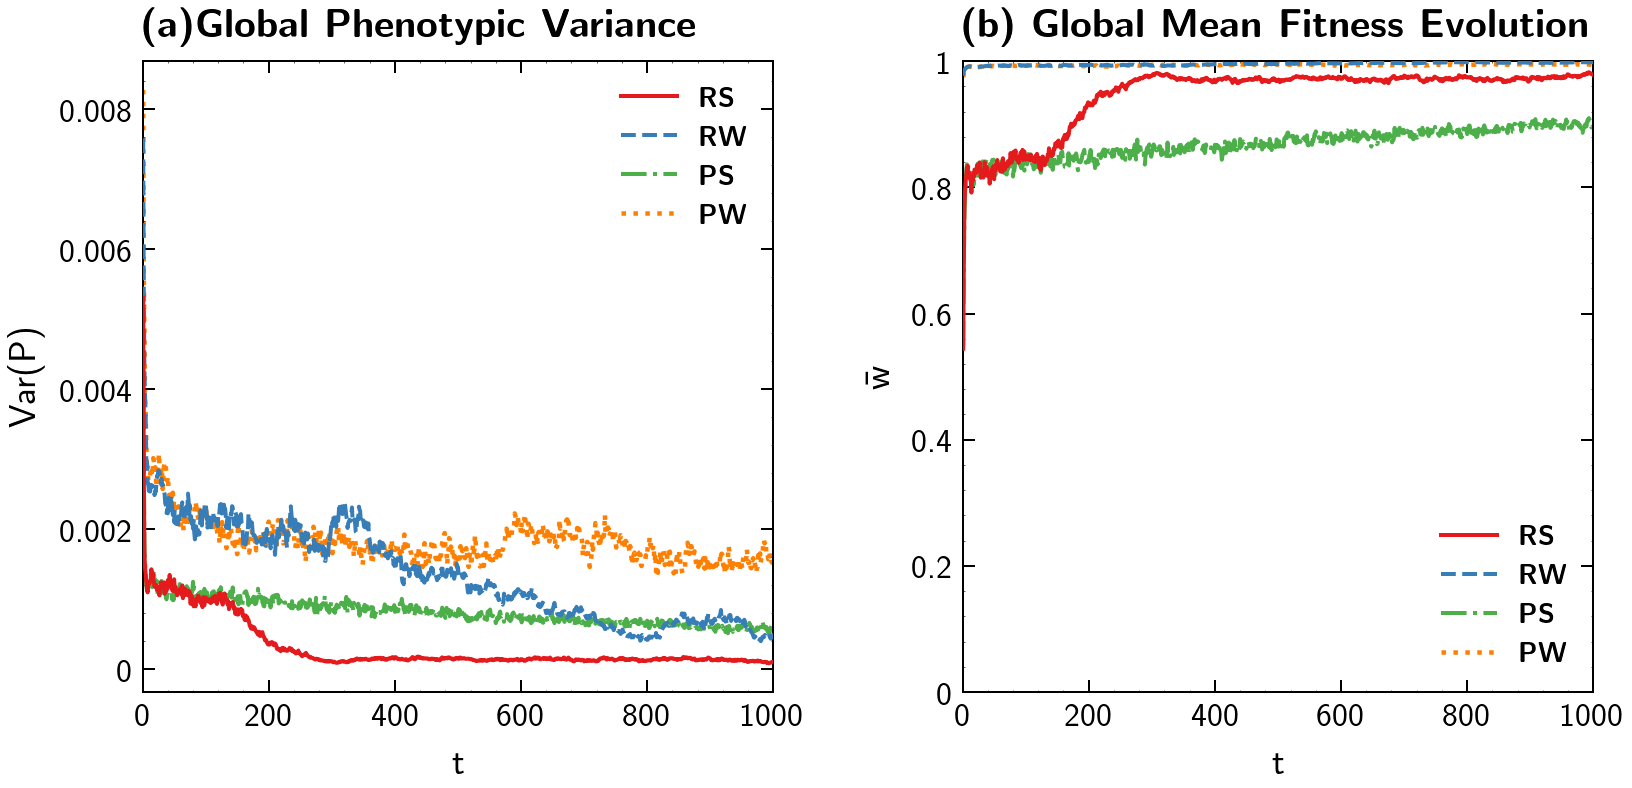

In [34]:
dados_extraidos = {}

for label, pasta in dirs.items():
    t_arr, var_arr, fit_arr = extrair_dinamica_global(pasta, t_max=1000)
    dados_extraidos[label] = {'t': t_arr, 'var': var_arr, 'fit': fit_arr}


fig = plt.figure(figsize=(26, 12))
gs = gridspec.GridSpec(1, 2, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0: 
        cfg = styles[label]
        ax1.plot(data['t'], data['var'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax1, major_size=SIZE_TICK, is_int=False)

ax1.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_ylabel(r'$\mathsf{Var(P)}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_title(r'\textbf{\textsf{(a)Global Phenotypic Variance}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax1.set_xlim(0, 1000)

ax1.legend(loc='best', frameon=False, fontsize=SIZE_LEGEND)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0:
        cfg = styles[label]
        ax2.plot(data['t'], data['fit'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax2, major_size=SIZE_TICK, is_int=False)

ax2.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_ylabel(r'$\mathsf{\bar{w}}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_title(r'\textbf{\textsf{(b) Global Mean Fitness Evolution}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1000)

ax2.legend(loc='lower right', frameon=False, fontsize=SIZE_LEGEND)

plt.savefig('SM_demographic_homo.pdf', bbox_inches='tight', dpi=300)
plt.show()